In [4]:
import pandas as pd #loading dataset
import numpy as np #numerical calculations
import matplotlib.pyplot as plt #data visualization
import seaborn as sns #advanced data visualization
from statsmodels.formula.api import ols #linear regression
from scipy import stats #statistical inference
from sklearn.preprocessing import LabelEncoder, StandardScaler #preprocessing before ml
from sklearn.model_selection import train_test_split,GridSearchCV# split our data 
from sklearn.linear_model import LinearRegression, Ridge,Lasso #Linear Regression model 
from sklearn.tree import DecisionTreeRegressor #tree model
from sklearn.ensemble import RandomForestRegressor #ensembling model
# we will add adaboost,catboost,xgboost,lightgbm



In [5]:
# load datatest
house_prices=pd.read_csv(r"house_prices_dataset.csv")
house_prices.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,year_built,year_renovated,zipcode,lat,long,price
0,3,1,2803,1153,1,0,0,3,9,2003,0,98001,47.660671,-121.785347,835016.23
1,5,3,783,9762,1,0,2,4,4,2019,0,98003,47.681937,-122.151515,326073.09
2,3,3,3412,2842,2,0,3,4,9,1961,1962,98002,47.182798,-121.792089,1025404.09
3,2,3,2222,9020,2,1,2,4,4,2008,1962,98004,47.440995,-121.871224,758764.79
4,4,1,4713,1584,2,0,3,4,5,1987,0,98005,47.701306,-122.416623,1314784.23


In [6]:
house_prices["waterfront"].value_counts()

waterfront
0    893
1    107
Name: count, dtype: int64

In [7]:
house_prices["view"].value_counts()

view
1    265
0    259
3    250
2    226
Name: count, dtype: int64

In [8]:
house_prices["condition"].value_counts()

condition
5    216
2    207
4    199
1    190
3    188
Name: count, dtype: int64

In [9]:
house_prices["grade"].value_counts()

grade
12    111
1      95
3      91
10     90
8      86
4      85
5      80
9      80
6      76
11     75
7      72
2      59
Name: count, dtype: int64

In [10]:
# drop zipcode column
house_prices=house_prices.drop("zipcode",axis=1)

In [11]:
house_prices.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,year_built,year_renovated,lat,long,price
0,3,1,2803,1153,1,0,0,3,9,2003,0,47.660671,-121.785347,835016.23
1,5,3,783,9762,1,0,2,4,4,2019,0,47.681937,-122.151515,326073.09
2,3,3,3412,2842,2,0,3,4,9,1961,1962,47.182798,-121.792089,1025404.09
3,2,3,2222,9020,2,1,2,4,4,2008,1962,47.440995,-121.871224,758764.79
4,4,1,4713,1584,2,0,3,4,5,1987,0,47.701306,-122.416623,1314784.23


In [12]:
# more info from our data
house_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bedrooms        1000 non-null   int64  
 1   bathrooms       1000 non-null   int64  
 2   sqft_living     1000 non-null   int64  
 3   sqft_lot        1000 non-null   int64  
 4   floors          1000 non-null   int64  
 5   waterfront      1000 non-null   int64  
 6   view            1000 non-null   int64  
 7   condition       1000 non-null   int64  
 8   grade           1000 non-null   int64  
 9   year_built      1000 non-null   int64  
 10  year_renovated  1000 non-null   int64  
 11  lat             1000 non-null   float64
 12  long            1000 non-null   float64
 13  price           1000 non-null   float64
dtypes: float64(3), int64(11)
memory usage: 109.5 KB


Exploratory Data Analysis
.price distribution

In [13]:
# Exploratory Data Analysis
house_prices.describe()


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,year_built,year_renovated,lat,long,price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2.988000,2.038000,2792.998000,5447.602000,1.501000,0.107000,1.467000,3.044000,6.651000,1985.746000,431.076000,47.443683,-122.009919,8.358796e+05
std,1.412746,0.819285,1288.747969,2614.572404,0.500249,0.309268,1.126135,1.424814,3.548773,20.809385,819.312098,0.198316,0.292534,3.271162e+05
min,1.000000,1.000000,600.000000,1001.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1950.000000,0.000000,47.100252,-122.497067,2.075845e+05
25%,2.000000,1.000000,1652.750000,3103.500000,1.000000,0.000000,0.000000,2.000000,4.000000,1968.000000,0.000000,47.275159,-122.259953,5.527969e+05
50%,3.000000,2.000000,2787.500000,5464.500000,2.000000,0.000000,1.000000,3.000000,7.000000,1986.000000,0.000000,47.450923,-122.024822,8.460296e+05
75%,4.000000,3.000000,3921.500000,7754.500000,2.000000,0.000000,2.250000,4.000000,10.000000,2004.000000,0.000000,47.609755,-121.748543,1.131182e+06
max,5.000000,3.000000,4996.000000,9992.000000,2.000000,1.000000,3.000000,5.000000,12.000000,2021.000000,2021.000000,47.798749,-121.500636,1.476859e+06


bedrooms data not skewed,mean and median are same

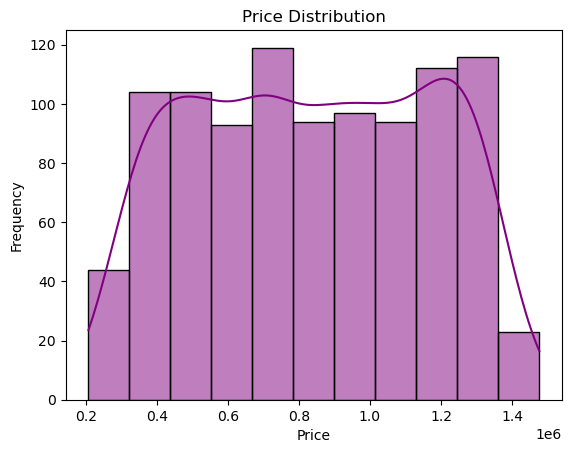

In [17]:
# price distribution
sns.histplot(data=house_prices,x="price",color="purple",kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Floors and prices
Does the number of floors influence the price?

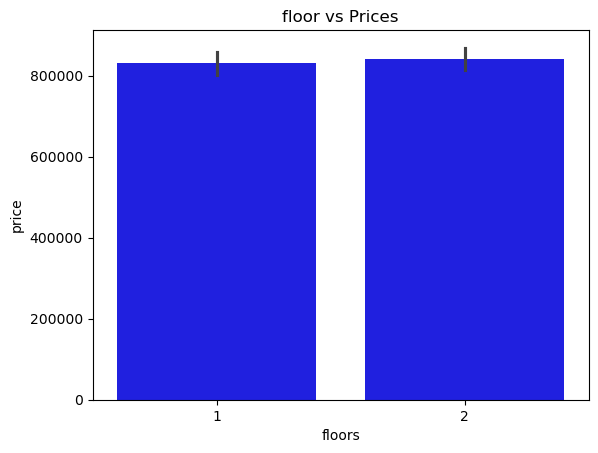

In [23]:
sns.barplot(data=house_prices,x="floors",y="price",color="blue")
plt.title("floor vs Prices")
plt.xlabel("floors")
plt.ylabel("price")
plt.show()